# Potato Harvest Detection — VDBorne Real Data
**BrabantHack 26 | Track Plant-Based 2 | Team 46**

## Goal
Detect and count **potatoes** and **contaminants** (stones + sticks) on a conveyor belt
using real camera footage from VDBorne harvesting machines.
Counts are aggregated per GPS position to produce a field-level contaminant zone map.

## Why 2 classes, not 3
Analysis of 9,311 blue bboxes from the existing classifier shows median aspect ratio 1.17 —
almost all contaminants are compact (stone-like). Sticks are too rare to train a reliable
separate class. Both map to the same business action (remove from belt), so one `contaminant`
class is sufficient and requires **zero manual labeling**.

## Pipeline
1. Load real images — 27k originals, 20k predictions
2. Inspect existing classifier (green = potato, blue = contaminant)
3. Auto-extract pseudo-labels — no manual labeling needed
4. Train YOLOv11s — 2 classes: `potato`, `contaminant`
5. Per-frame counts → GPS contaminant zone map
6. Export GeoJSON + NDJSON


## 1. Install Dependencies

## 2. Paths & Config
Two classes only. No manual labeling required — both classes come from the existing classifier's bboxes.

In [22]:
from pathlib import Path
import random, json, shutil
import numpy as np
import cv2
import matplotlib.pyplot as plt

ROOT        = Path('..')
ORIG_DIR    = ROOT / 'notebooks/data/originals'
PRED_DIR    = ROOT / 'notebooks/data/predictions'
DATA_DIR    = ROOT / 'notebooks/data/yolo'
RESULTS_DIR = ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

CLASSES = ['potato', 'contaminant']  # stone + stick merged — same action, no manual labels needed
NC = len(CLASSES)

COLOR_POTATO      = (0, 255, 0)   # green in prediction images
COLOR_CONTAMINANT = (255, 0, 0)   # blue  in prediction images

print(f'Originals   : {len(list(ORIG_DIR.glob("*.jpg")))}')
print(f'Predictions : {len(list(PRED_DIR.glob("*.jpg")))}')
print(f'Classes     : {CLASSES}')


Originals   : 27774
Predictions : 20630
Classes     : ['potato', 'contaminant']


## 3. Inspect Existing Classifier Output
Shows 6 random original/prediction pairs. Green boxes = potatoes, blue boxes = contaminants.
The prediction images are the source of all labels — no human annotation required.

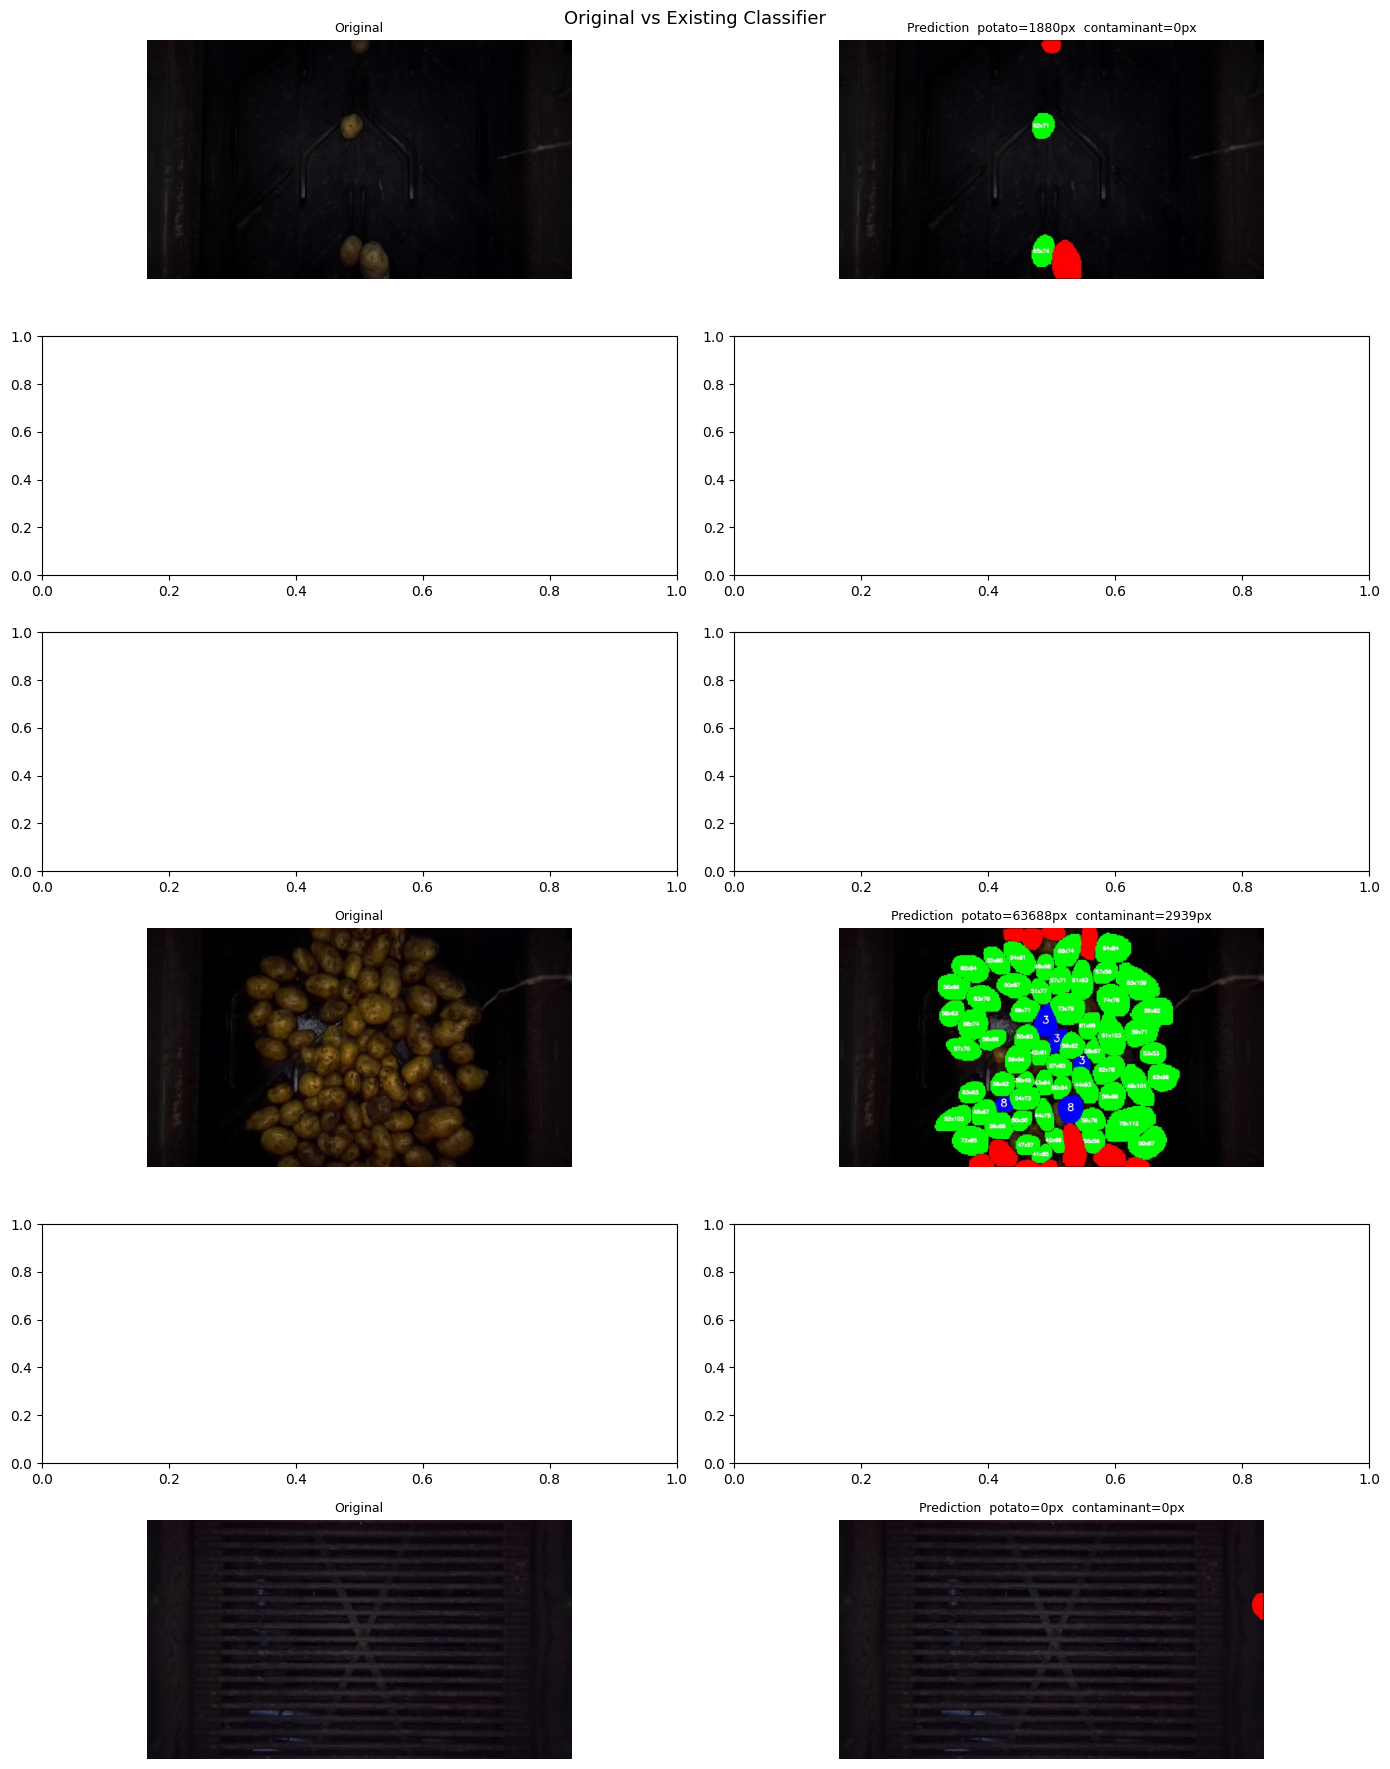

In [23]:
def count_color(img, color_bgr, tol=40):
    lo = np.array([max(0, c-tol) for c in color_bgr], np.uint8)
    hi = np.array([min(255, c+tol) for c in color_bgr], np.uint8)
    return int(cv2.inRange(img, lo, hi).sum() / 255)

def show_pairs(n=6):
    preds = random.sample(list(PRED_DIR.glob('*.jpg')), n)
    fig, axes = plt.subplots(n, 2, figsize=(14, n*3))
    for i, pred_path in enumerate(preds):
        orig_name = pred_path.name.replace('-prediction-', '-picture-')
        orig_path = ORIG_DIR / orig_name
        if not orig_path.exists(): continue
        img_o = cv2.cvtColor(cv2.imread(str(orig_path)), cv2.COLOR_BGR2RGB)
        img_p = cv2.cvtColor(cv2.imread(str(pred_path)), cv2.COLOR_BGR2RGB)
        g = count_color(cv2.imread(str(pred_path)), COLOR_POTATO)
        b = count_color(cv2.imread(str(pred_path)), COLOR_CONTAMINANT)
        axes[i,0].imshow(img_o); axes[i,0].set_title('Original', fontsize=9)
        axes[i,1].imshow(img_p)
        axes[i,1].set_title(f'Prediction  potato={g}px  contaminant={b}px', fontsize=9)
        for ax in axes[i]: ax.axis('off')
    plt.suptitle('Original vs Existing Classifier', fontsize=13)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'pair_inspection.png', dpi=100)
    plt.show()

show_pairs(6)


## 4. Pseudo-Label Extraction
Automatically extracts YOLO-format bounding boxes from the existing classifier's colored overlays.

**How it works:**
1. For each prediction image, mask the green (potato) and blue (contaminant) pixels
2. Dilate the mask to close gaps in the drawn bbox outlines
3. Find contours → compute bounding rect → convert to normalized YOLO format
4. Copy the **original** (clean) image + label file into the YOLO dataset folder

Dataset is split 70/20/10 train/val/test. `MAX_IMAGES=3000` caps for hackathon speed — remove for full training.

In [24]:
def extract_pseudo_labels(pred_img_bgr, img_w, img_h):
    """Extract YOLO bboxes from green (potato=0) and blue (contaminant=1) regions."""
    labels = []
    for cls_id, color in [(0, COLOR_POTATO), (1, COLOR_CONTAMINANT)]:
        lo = np.array([max(0, c-40) for c in color], np.uint8)
        hi = np.array([min(255, c+40) for c in color], np.uint8)
        mask = cv2.inRange(pred_img_bgr, lo, hi)
        mask = cv2.dilate(mask, np.ones((5,5), np.uint8), iterations=2)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for c in contours:
            x, y, w, h = cv2.boundingRect(c)
            if w < 15 or h < 15: continue
            labels.append(f'{cls_id} {(x+w/2)/img_w:.6f} {(y+h/2)/img_h:.6f} '
                          f'{w/img_w:.6f} {h/img_h:.6f}')
    return labels


SPLITS = {'train': 0.70, 'val': 0.20, 'test': 0.10}
MAX_IMAGES = 3000

for split in SPLITS:
    (DATA_DIR / split / 'images').mkdir(parents=True, exist_ok=True)
    (DATA_DIR / split / 'labels').mkdir(parents=True, exist_ok=True)

all_preds = list(PRED_DIR.glob('*.jpg'))
random.shuffle(all_preds)
all_preds = all_preds[:MAX_IMAGES]
n = len(all_preds)
cut1, cut2 = int(n*0.70), int(n*0.90)
split_map = ['train']*cut1 + ['val']*(cut2-cut1) + ['test']*(n-cut2)

written = {'train': 0, 'val': 0, 'test': 0}
for pred_path, split in zip(all_preds, split_map):
    orig_path = ORIG_DIR / pred_path.name.replace('-prediction-', '-picture-')
    if not orig_path.exists(): continue
    pred_bgr = cv2.imread(str(pred_path))
    if pred_bgr is None: continue
    h, w = pred_bgr.shape[:2]
    labels = extract_pseudo_labels(pred_bgr, w, h)
    if not labels: continue
    stem = pred_path.stem.replace('-prediction-', '-')
    shutil.copy2(orig_path, DATA_DIR / split / 'images' / f'{stem}.jpg')
    (DATA_DIR / split / 'labels' / f'{stem}.txt').write_text('\n'.join(labels))
    written[split] += 1

print('Dataset built (no manual labeling needed):')
for s, c in written.items(): print(f'  {s}: {c} images')


KeyboardInterrupt: 

## 5. data.yaml
YOLO config file pointing to the dataset folders and defining the 2 class names.

In [ ]:
yaml_content = f"""path: {DATA_DIR.resolve()}
train: train/images
val:   val/images
test:  test/images
nc: {NC}
names: {CLASSES}
"""
DATASET_YAML = DATA_DIR / 'data.yaml'
DATASET_YAML.write_text(yaml_content)
print(yaml_content)


## 6. Minimal Augmentation
Only transforms that reflect **real variation** in the VDBorne dataset are kept:

| Transform | Why |
|---|---|
| `HorizontalFlip` | Belt is left-right symmetric — objects appear from either side |
| `MotionBlur` | Belt is moving during capture — some frames have natural blur |
| `RandomBrightnessContrast` | Lighting differs between the 3 cameras and across seasons |

Everything else (noise, sun flare, hue shifts, dropout) was removed — those simulate
conditions that do not occur on a fixed indoor/outdoor conveyor belt.


In [ ]:
import albumentations as A

augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.MotionBlur(blur_limit=(3, 7), p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.15, p=0.4),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.3))

print('Minimal augmentation pipeline ready')


## 7. YOLOv11s Training
Train a **YOLOv11s** (small) model on the pseudo-labeled real images.

No augmentation is applied — the model trains on images from the exact same camera setup
it will run on in production, so artificial variation would only add noise.

- `EPOCHS=5` for a quick smoke test; set to **50** for real training (~15–20 min on GPU)
- `imgsz=640` matches the camera resolution (360×640)
- `batch=16` on GPU, reduce to `8` if running on CPU
- Best checkpoint saved to `results/yolo11s_2class/weights/best.pt`


In [ ]:
from ultralytics import YOLO
import torch

print(f'PyTorch: {torch.__version__}')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

model = YOLO('yolo11s.pt')
EPOCHS = 5  # ← set to 50 for real training

results = model.train(
    data=str(DATASET_YAML),
    epochs=EPOCHS,
    imgsz=640,
    batch=8,
    device=device,
    mosaic=0.8,
    degrees=5,
    flipud=0.3,
    fliplr=0.5,
    lr0=0.01,
    lrf=0.005,
    project=str(RESULTS_DIR),
    name='yolo11s_2class',
    exist_ok=True,
    verbose=True,
)

BEST_MODEL = Path(results.save_dir) / 'weights/best.pt'
print(f'Best model: {BEST_MODEL}')


## 8. Inference — Per-Frame Counts
Run the trained model on the test set. For each frame, count potatoes and contaminants.

Filename format: `{camera}__{timestamp}-{timestamp}.jpg` — the timestamp links to GPS.

- `contaminant_rate` = contaminants / (potatoes + contaminants) × 100
- This is the primary KPI — high rate = field zone needs attention

In [ ]:
from ultralytics import YOLO
import pandas as pd

infer_model = YOLO(str(BEST_MODEL))
test_imgs = list((DATA_DIR / 'test/images').glob('*.jpg'))
print(f'Inference on {len(test_imgs)} test images...')

records = []
for img_path in test_imgs:
    result = infer_model(str(img_path), verbose=False)[0]
    counts = {'potato': 0, 'contaminant': 0}
    for box in result.boxes:
        counts[CLASSES[int(box.cls)]] += 1
    parts = img_path.stem.split('__')
    cam = parts[0] if len(parts) > 1 else 'unknown'
    ts  = parts[1][:19] if len(parts) > 1 else img_path.stem[:19]
    records.append({'cam': cam, 'ts': ts, **counts})

det_df = pd.DataFrame(records)
det_df['contaminant_rate'] = (
    det_df['contaminant'] /
    (det_df['potato'] + det_df['contaminant']).replace(0, 1) * 100
).round(1)

print(det_df[['potato','contaminant','contaminant_rate']].describe().round(2))
print(f'\nFrames with contaminants : {(det_df.contaminant > 0).sum()}/{len(det_df)}')
print(f'Avg contaminant rate     : {det_df.contaminant_rate.mean():.1f}%')


## 9. GPS Contaminant Zone Map
Link detection counts to GPS and cluster high-contaminant positions into field risk zones.

**To use real GPS data:** replace the simulation block with `pd.read_csv('../data/gps_track.csv')` (columns: `ts`, `lat`, `lon`).

DBSCAN groups nearby frames with >15% contaminant rate into zones:
- `eps=0.0001` ≈ 10m radius
- `min_samples=3` — minimum 3 frames to form a zone
- Zones are classified `high` (>30%) or `medium` risk

In [ ]:
from shapely.geometry import MultiPoint
from sklearn.cluster import DBSCAN

# Simulated GPS — replace with real data if available
# det_df = det_df.merge(pd.read_csv('../data/gps_track.csv'), on='ts')
np.random.seed(42)
n = len(det_df)
base_lat, base_lon = 51.350, 5.150
lats, lons = [], []
for row in range(10):
    row_lons = np.linspace(base_lon, base_lon + 0.003, n // 10 + 1)
    if row % 2: row_lons = row_lons[::-1]
    row_lat = base_lat + row * 0.0002
    for lon in row_lons[:n // 10]:
        lats.append(row_lat + np.random.normal(0, 0.00001))
        lons.append(lon  + np.random.normal(0, 0.00001))
det_df = det_df.iloc[:len(lats)].copy()
det_df['lat'] = lats[:len(det_df)]
det_df['lon'] = lons[:len(det_df)]

high = det_df[det_df.contaminant_rate > 15].copy()
zones = []
if len(high) > 3:
    lbls = DBSCAN(eps=0.0001, min_samples=3).fit_predict(high[['lat','lon']].values)
    high['zone_id'] = lbls
    for lbl in set(lbls):
        if lbl == -1: continue
        cluster = high[high.zone_id == lbl]
        if len(cluster) < 3: continue
        poly = MultiPoint([(lo, la) for la, lo in
                           cluster[['lat','lon']].values]).convex_hull.buffer(0.00015)
        avg = cluster.contaminant_rate.mean()
        zones.append({'zone_id': f'zone_{lbl+1}',
                      'risk': 'high' if avg > 30 else 'medium',
                      'avg_contaminant_rate': round(avg, 1),
                      'avg_contaminants_per_frame': round(cluster.contaminant.mean(), 1),
                      'n_frames': len(cluster),
                      'geometry': poly})
    print(f'Detected {len(zones)} contaminant zone(s)')
    for z in zones:
        print(f"  {z['zone_id']}: {z['risk']}, {z['avg_contaminant_rate']}% rate, {z['n_frames']} frames")
else:
    print('Not enough high-contaminant frames for clustering')


## 10. Visualise
- **Left:** field scatter map coloured by contaminant rate, with risk zone polygons
- **Right:** contaminant count over the harvest track with warning threshold

Saved to `results/contaminant_map.png`.

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sc = ax1.scatter(det_df.lon, det_df.lat, c=det_df.contaminant_rate,
                 cmap='OrRd', s=20, alpha=0.8, vmin=0, vmax=50)
plt.colorbar(sc, ax=ax1, label='Contaminant rate %')
for z in zones:
    x, y = z['geometry'].exterior.xy
    col = '#cc0000' if z['risk'] == 'high' else '#ff8800'
    ax1.fill(x, y, alpha=0.25, color=col)
    ax1.plot(x, y, color=col, lw=2)
    ax1.annotate(z['zone_id'], (float(np.mean(x)), float(np.mean(y))),
                 fontsize=8, ha='center', color=col, fontweight='bold')
ax1.set_title('Field Contaminant Map', fontsize=12)
ax1.set_xlabel('Longitude'); ax1.set_ylabel('Latitude')

ax2.bar(range(len(det_df)), det_df.contaminant, color='#c0392b', alpha=0.7, label='Contaminants')
ax2.axhline(3, color='orange', ls='--', lw=1.5, label='Warning (3/frame)')
ax2.set_xlabel('Frame'); ax2.set_ylabel('Contaminants per frame')
ax2.set_title('Contaminant Count Along Harvest Track', fontsize=12)
ax2.legend(fontsize=9)

plt.suptitle('VDBorne — Harvest Contaminant Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'contaminant_map.png', dpi=120)
plt.show()
print('Saved: results/contaminant_map.png')


## 11. Export — GeoJSON + NDJSON
- **`contaminant_zones.geojson`** — polygon features per risk zone, ready for QGIS / Leaflet / dashboard
- **`detections_batch.ndjson`** — one record per frame for Snowflake `COPY INTO` or S3

In [ ]:
from shapely.geometry import mapping

if zones:
    geojson = {'type': 'FeatureCollection', 'features': [
        {'type': 'Feature',
         'geometry': mapping(z['geometry']),
         'properties': {k: v for k, v in z.items() if k != 'geometry'}}
        for z in zones
    ]}
    (RESULTS_DIR / 'contaminant_zones.geojson').write_text(json.dumps(geojson, indent=2))
    print(f'GeoJSON exported: {len(zones)} zones')

ndjson_path = RESULTS_DIR / 'detections_batch.ndjson'
with open(ndjson_path, 'w') as f:
    for r in det_df.to_dict('records'):
        f.write(json.dumps(r) + '\n')
print(f'NDJSON exported: {len(det_df)} records')

print('\n=== KPI Summary ===')
print(f'Frames analysed          : {len(det_df)}')
print(f'Avg potatoes / frame     : {det_df.potato.mean():.1f}')
print(f'Avg contaminants / frame : {det_df.contaminant.mean():.1f}')
print(f'Avg contaminant rate     : {det_df.contaminant_rate.mean():.1f}%')
print(f'High-risk zones          : {sum(z["risk"]=="high" for z in zones)}')


## Setup: AWS — Step-by-Step for Beginners

### What is AWS and why do we use it?
AWS (Amazon Web Services) is a cloud platform. We use two services:
- **S3** (Simple Storage Service) — a cloud hard drive to store our dataset and trained model
- **EC2** (Elastic Compute Cloud) — a cloud computer with a GPU to run the training fast

Training on a GPU in the cloud takes ~20 minutes instead of ~2 hours on a laptop CPU.

---

### Step 1 — Install the AWS CLI and boto3
```bash
pip install boto3 awscli -q
```

### Step 2 — Get your AWS credentials
Someone on your team (or the hackathon organiser) should provide:
- `AWS_ACCESS_KEY_ID` — like a username
- `AWS_SECRET_ACCESS_KEY` — like a password
- The **S3 bucket name** you have access to
- The **region** (e.g. `eu-west-1` for Ireland)

### Step 3 — Set credentials in your terminal
Open a terminal (not inside Jupyter) and run:
```bash
export AWS_ACCESS_KEY_ID=AKIA...
export AWS_SECRET_ACCESS_KEY=your_secret_key
export AWS_DEFAULT_REGION=eu-west-1
export AWS_S3_BUCKET=your-bucket-name
```
Then launch Jupyter from **the same terminal** so it inherits these variables.

### Step 4 — Verify your access
Run this to check you can reach S3:
```bash
aws s3 ls s3://your-bucket-name
```
If it lists files (or shows empty), you're connected. If it says `AccessDenied`, check the key.

### Step 5 — For cell 13 (launching the EC2 instance) you also need:
- A **key pair** — go to AWS Console → EC2 → Key Pairs → Create key pair → save the `.pem` file
- A **security group** — go to EC2 → Security Groups → find the default one and copy its `sg-...` ID
- An **IAM role** called `EC2S3Access` with `AmazonS3FullAccess` policy attached
  (ask the hackathon organiser or go to IAM → Roles → Create role → EC2 → attach S3FullAccess)

> **Tip:** If this feels like too many steps, just run training locally with `EPOCHS=10` and `batch=4`.
> It will take longer but produces a working model without any AWS setup.


## 12. Upload Dataset to S3 (AWS)
Upload the YOLO dataset to S3 so the EC2 training instance can access it.

**Before running:** set your AWS credentials via environment variables or `aws configure`.
The S3 bucket name below should match what your team was given.

This cell zips the dataset folder and uploads it to S3. Takes ~1–2 min on a good connection.

In [ ]:
import boto3, zipfile, os
from pathlib import Path

# ── Configure ────────────────────────────────────────────────────
S3_BUCKET = os.environ.get('AWS_S3_BUCKET', 'brabanthack-team46')  # ← set your bucket name
S3_PREFIX = 'potato-detection'

# Zip the YOLO dataset
zip_path = Path('../notebooks/data/yolo_dataset.zip')
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in DATA_DIR.rglob('*'):
        if f.is_file():
            zf.write(f, f.relative_to(DATA_DIR.parent))
print(f'Zipped: {zip_path}  ({zip_path.stat().st_size / 1024 / 1024:.1f} MB)')

# Upload to S3
s3 = boto3.client('s3')
s3.upload_file(str(zip_path), S3_BUCKET, f'{S3_PREFIX}/yolo_dataset.zip',
               Callback=lambda b: print(f'  Uploaded {b} bytes...'))
print(f'Uploaded to s3://{S3_BUCKET}/{S3_PREFIX}/yolo_dataset.zip')


## 13. Launch EC2 GPU Training Instance
**Run this once to start a `g4dn.xlarge` spot instance** (T4 GPU, ~\$0.16/hr spot).
The instance downloads the dataset from S3, trains for 50 epochs, and uploads `best.pt` back to S3.

**Prerequisites:**
- AWS credentials with EC2 + S3 permissions
- A key pair named `brabanthack` (or change `KEY_NAME` below)
- A security group allowing SSH (port 22)

**Training time estimate:** ~15–20 min for 50 epochs on T4 GPU.

In [ ]:
import boto3, textwrap

KEY_NAME       = 'brabanthack'          # ← your EC2 key pair name
SECURITY_GROUP = 'sg-xxxxxxxxxx'        # ← your security group id
S3_BUCKET      = os.environ.get('AWS_S3_BUCKET', 'brabanthack-team46')
S3_PREFIX      = 'potato-detection'

# User-data script runs on instance startup
user_data = textwrap.dedent(f"""
    #!/bin/bash
    set -e
    pip install ultralytics boto3 -q
    aws s3 cp s3://{S3_BUCKET}/{S3_PREFIX}/yolo_dataset.zip /tmp/dataset.zip
    unzip -q /tmp/dataset.zip -d /tmp/
    python3 - <<'PYEOF'
from ultralytics import YOLO
from pathlib import Path
import boto3

model = YOLO('yolo11s.pt')
results = model.train(
    data='/tmp/yolo/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    device='cuda',
    mosaic=0.8, degrees=5, flipud=0.3, fliplr=0.5,
    lr0=0.01, lrf=0.005,
    project='/tmp/results', name='yolo11s_2class', exist_ok=True,
)
best = Path(results.save_dir) / 'weights/best.pt'
boto3.client('s3').upload_file(str(best), '{S3_BUCKET}', '{S3_PREFIX}/best.pt')
print('Model uploaded to S3')
PYEOF
    # Auto-shutdown when done
    shutdown -h now
""")

ec2 = boto3.client('ec2', region_name='eu-west-1')  # ← change region if needed
resp = ec2.run_instances(
    ImageId='ami-0c02fb55956c7d316',   # Amazon Linux 2 with DLAMI — update for your region
    InstanceType='g4dn.xlarge',
    MinCount=1, MaxCount=1,
    KeyName=KEY_NAME,
    SecurityGroupIds=[SECURITY_GROUP],
    UserData=user_data,
    InstanceMarketOptions={'MarketType': 'spot'},   # use spot for cost savings
    IamInstanceProfile={'Name': 'EC2S3Access'},     # needs S3 read/write permission
    TagSpecifications=[{'ResourceType': 'instance',
                        'Tags': [{'Key': 'Name', 'Value': 'brabanthack-training'}]}],
)
instance_id = resp['Instances'][0]['InstanceId']
print(f'Instance launched: {instance_id}')
print(f'Monitor at: https://eu-west-1.console.aws.amazon.com/ec2/v2/home#Instances')
print(f'When training completes, best.pt will be at:')
print(f'  s3://{S3_BUCKET}/{S3_PREFIX}/best.pt')


## 14. Download Trained Model from S3
After the EC2 instance shuts itself down (~20 min), download `best.pt` and run inference locally.
Then continue with cells 8–11 as normal.

In [ ]:
import boto3

S3_BUCKET = os.environ.get('AWS_S3_BUCKET', 'brabanthack-team46')
S3_PREFIX = 'potato-detection'

s3 = boto3.client('s3')
local_model = RESULTS_DIR / 'best_aws.pt'
s3.download_file(S3_BUCKET, f'{S3_PREFIX}/best.pt', str(local_model))
print(f'Downloaded: {local_model}')

# Point BEST_MODEL at the downloaded file
BEST_MODEL = local_model
print('Ready — continue from cell 8 (Inference)')


## Setup: Snowflake Credentials

Set the following environment variables **before running cell 15**.
Do this in the terminal where you launched Jupyter, or add them to a `.env` file (never commit it).

```bash
export SNOWFLAKE_ACCOUNT=your_account        # e.g. xy12345.eu-west-1
export SNOWFLAKE_USER=your_username
export SNOWFLAKE_PASSWORD=your_password
export SNOWFLAKE_DATABASE=vdborne            # or the database you were given
export SNOWFLAKE_SCHEMA=harvest
export SNOWFLAKE_WAREHOUSE=compute_wh
```

Install the Snowflake connector if not yet installed:
```bash
pip install snowflake-connector-python snowflake-sqlalchemy -q
```

**Two tables will be created and populated:**

| Table | Content |
|---|---|
| `DETECTIONS` | One row per frame: timestamp, camera, GPS, potato count, contaminant count, rate |
| `RISK_ZONES` | One row per risk zone: zone id, risk level, avg rate, geometry as WKT |

The `geometry_wkt` column in `RISK_ZONES` can be visualised directly in a Snowflake geo dashboard or Streamlit.


## 15. Load Detection Results into Snowflake
Push the per-frame detection records and risk zones into Snowflake for dashboarding.

**Prerequisites:** set these environment variables before running:
```
export SNOWFLAKE_ACCOUNT=your_account
export SNOWFLAKE_USER=your_user
export SNOWFLAKE_PASSWORD=your_password
export SNOWFLAKE_DATABASE=vdborne       # or whatever db you were given
export SNOWFLAKE_SCHEMA=harvest
export SNOWFLAKE_WAREHOUSE=compute_wh
```

Two tables are created/upserted:
- `DETECTIONS` — one row per frame: ts, cam, lat, lon, potato, contaminant, contaminant_rate
- `RISK_ZONES` — one row per detected zone: zone_id, risk level, avg rate, geometry as WKT

In [ ]:
import os
import snowflake.connector
from snowflake.connector.pandas_tools import write_pandas

SF_ACCOUNT   = os.environ.get('SNOWFLAKE_ACCOUNT', '')
SF_USER      = os.environ.get('SNOWFLAKE_USER', '')
SF_PASSWORD  = os.environ.get('SNOWFLAKE_PASSWORD', '')
SF_DATABASE  = os.environ.get('SNOWFLAKE_DATABASE', 'vdborne')
SF_SCHEMA    = os.environ.get('SNOWFLAKE_SCHEMA', 'harvest')
SF_WAREHOUSE = os.environ.get('SNOWFLAKE_WAREHOUSE', 'compute_wh')

if not SF_ACCOUNT:
    print('Set SNOWFLAKE_* env vars to enable this cell')
else:
    conn = snowflake.connector.connect(
        account=SF_ACCOUNT, user=SF_USER, password=SF_PASSWORD,
        database=SF_DATABASE, schema=SF_SCHEMA, warehouse=SF_WAREHOUSE,
    )
    cur = conn.cursor()

    # Create tables
    cur.execute("""
        CREATE TABLE IF NOT EXISTS DETECTIONS (
            cam VARCHAR, ts VARCHAR,
            potato INTEGER, contaminant INTEGER,
            contaminant_rate FLOAT,
            lat FLOAT, lon FLOAT
        )
    """)
    cur.execute("""
        CREATE TABLE IF NOT EXISTS RISK_ZONES (
            zone_id VARCHAR, risk VARCHAR,
            avg_contaminant_rate FLOAT,
            avg_contaminants_per_frame FLOAT,
            n_frames INTEGER,
            geometry_wkt VARCHAR
        )
    """)

    # Upload detections
    upload_cols = ['cam','ts','potato','contaminant','contaminant_rate','lat','lon']
    write_pandas(conn, det_df[upload_cols], 'DETECTIONS',
                 database=SF_DATABASE, schema=SF_SCHEMA)
    print(f'Uploaded {len(det_df)} detection records to Snowflake')

    # Upload risk zones
    if zones:
        import pandas as pd
        zones_df = pd.DataFrame([{
            'zone_id': z['zone_id'],
            'risk': z['risk'],
            'avg_contaminant_rate': z['avg_contaminant_rate'],
            'avg_contaminants_per_frame': z['avg_contaminants_per_frame'],
            'n_frames': z['n_frames'],
            'geometry_wkt': z['geometry'].wkt,
        } for z in zones])
        write_pandas(conn, zones_df, 'RISK_ZONES',
                     database=SF_DATABASE, schema=SF_SCHEMA)
        print(f'Uploaded {len(zones_df)} risk zones to Snowflake')

    conn.close()
    print('Snowflake connection closed')
